# Day 4 — Attention & Transformers

## Arabic Sentiment Analysis with MARBERT

In this notebook, we explore Attention and Transformer-based models
for Arabic sentiment analysis.

We will:
- Prepare and analyze an Arabic sentiment dataset.
- Fine-tune a pre-trained MARBERT model.
- Evaluate the model using Accuracy, Precision, Recall, and Macro F1.
- Analyze classification errors using a Confusion Matrix.
- Compare MARBERT with the LSTM model from Day 3.
- Decide which model is more suitable as the core model for the project.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


##  Load the Arabic Sentiment Dataset

We use the Arabic Sentiment Twitter Corpus for binary Arabic
sentiment classification.

The dataset contains two sentiment classes:

- Negative
- Positive

A balanced subset will be created to reduce class imbalance
and provide a fair comparison between LSTM and MARBERT.

In [6]:
from datasets import load_dataset

dataset = load_dataset(
    "arbml/Arabic_Sentiment_Twitter_Corpus"
)

print(dataset)

README.md:   0%|          | 0.00/2.52k [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.13MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  783kB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/47000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11751 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['tweet', 'label'],
        num_rows: 47000
    })
    test: Dataset({
        features: ['tweet', 'label'],
        num_rows: 11751
    })
})


##  Dataset Overview

Before preprocessing, we inspect the dataset structure, sample tweets,
and sentiment label distribution.

This helps us understand the data and verify whether the classes
are balanced before creating our training, validation, and test sets.

In [7]:
# Convert datasets to pandas
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nColumns:")
print(train_df.columns.tolist())

print("\nSample tweets:")
display(train_df.head())

Train shape: (47000, 2)
Test shape: (11751, 2)

Columns:
['tweet', 'label']

Sample tweets:


,tweet,label
0,اعترف ان بتس كانو شوي شوي يجيبو راسي لكن اليوم...,0
1,توقعت اذا جات داريا بشوفهم كاملين بس لي للحين ...,0
2,#الاهلي_الهلال اكتب توقعك لنتيجة لقاء الهلال و...,0
3,نعمة المضادات الحيوية . تضع قطرة💧مضاد بنسلين ع...,0
4,الدودو جايه تكمل علي 💔,0


In [8]:
print("Training label distribution:")
print(train_df["label"].value_counts().sort_index())

print("\nTest label distribution:")
print(test_df["label"].value_counts().sort_index())

Training label distribution:
label
0    23121
1    23879
Name: count, dtype: int64

Test label distribution:
label
0    5781
1    5970
Name: count, dtype: int64


In [9]:
print("Training Set:")
print(train_df.info())

print("\nTest Set:")
print(test_df.info())

Training Set:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47000 entries, 0 to 46999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tweet   47000 non-null  object
 1   label   47000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 734.5+ KB
None

Test Set:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11751 entries, 0 to 11750
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tweet   11751 non-null  object
 1   label   11751 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 183.7+ KB
None


In [10]:
print("Missing values in training data:")
print(train_df.isnull().sum())

print("\nMissing values in test data:")
print(test_df.isnull().sum())

Missing values in training data:
tweet    0
label    0
dtype: int64

Missing values in test data:
tweet    0
label    0
dtype: int64


In [11]:
print("Duplicate tweets in training data:",
      train_df["tweet"].duplicated().sum())

print("Duplicate tweets in test data:",
      test_df["tweet"].duplicated().sum())

Duplicate tweets in training data: 16638
Duplicate tweets in test data: 2786


In [12]:
train_tweets = set(
    train_df["tweet"].astype(str)
)

test_tweets = set(
    test_df["tweet"].astype(str)
)

overlap = train_tweets.intersection(test_tweets)

print("Unique tweets in training:", len(train_tweets))
print("Unique tweets in test:", len(test_tweets))
print("Tweets appearing in both:", len(overlap))

Unique tweets in training: 30362
Unique tweets in test: 8965
Tweets appearing in both: 2605


##  Remove Train-Test Data Leakage

We identified tweets that appear in both the training and test sets.

To ensure a fair evaluation, we remove overlapping tweets from
the test set so that no identical tweet is present in both datasets.

This prevents data leakage and provides a more reliable estimate
of the model's generalization performance.

In [13]:
# Remove tweets from the test set that also appear in training
test_df_clean = test_df[
    ~test_df["tweet"].isin(train_tweets)
].copy()

print("Original test shape:", test_df.shape)
print("Clean test shape:", test_df_clean.shape)

print(
    "Removed overlapping tweets:",
    len(test_df) - len(test_df_clean)
)

Original test shape: (11751, 2)
Clean test shape: (6497, 2)
Removed overlapping tweets: 5254


In [14]:
# Remove duplicate tweets from training
train_df_clean = train_df.drop_duplicates(
    subset="tweet"
).copy()

print("Original training shape:", train_df.shape)
print("Clean training shape:", train_df_clean.shape)

print(
    "Removed duplicate training tweets:",
    len(train_df) - len(train_df_clean)
)

Original training shape: (47000, 2)
Clean training shape: (30362, 2)
Removed duplicate training tweets: 16638


In [15]:
print("Training distribution after duplicate removal:")
print(
    train_df_clean["label"]
    .value_counts()
    .sort_index()
)

print("\nTest distribution after leakage removal:")
print(
    test_df_clean["label"]
    .value_counts()
    .sort_index()
)

Training distribution after duplicate removal:
label
0    15437
1    14925
Name: count, dtype: int64

Test distribution after leakage removal:
label
0    3361
1    3136
Name: count, dtype: int64


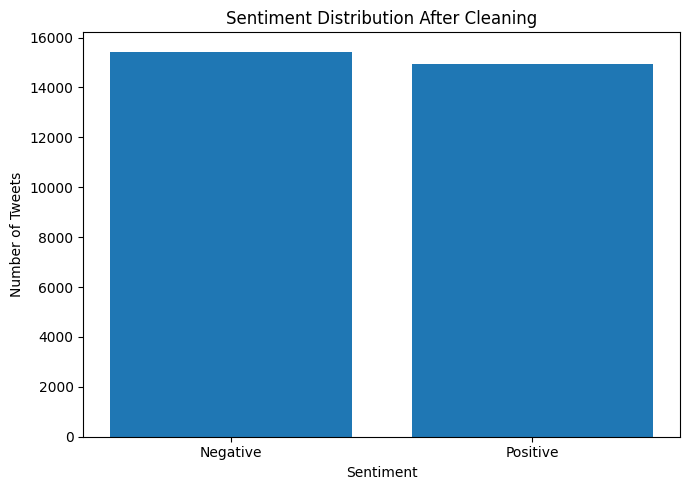

In [17]:
train_counts = (
    train_df_clean["label"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 5))

plt.bar(
    ["Negative", "Positive"],
    train_counts.values
)

plt.title("Sentiment Distribution After Cleaning")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.tight_layout()
plt.show()

In [16]:
# Calculate tweet length in characters
train_df_clean["tweet_length"] = (
    train_df_clean["tweet"]
    .astype(str)
    .str.len()
)

test_df_clean["tweet_length"] = (
    test_df_clean["tweet"]
    .astype(str)
    .str.len()
)

print("Training tweet length statistics:")
print(train_df_clean["tweet_length"].describe())

print("\nTest tweet length statistics:")
print(test_df_clean["tweet_length"].describe())

Training tweet length statistics:
count    30362.000000
mean        56.438179
std         35.673792
min          5.000000
25%         25.000000
50%         47.000000
75%         89.000000
max        140.000000
Name: tweet_length, dtype: float64

Test tweet length statistics:
count    6497.000000
mean       53.905187
std        35.196006
min         6.000000
25%        23.000000
50%        44.000000
75%        84.000000
max       139.000000
Name: tweet_length, dtype: float64


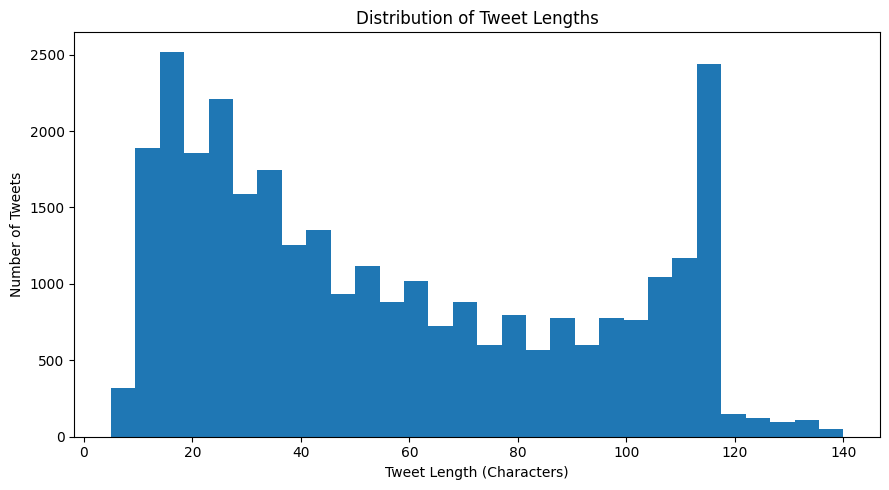

In [18]:
plt.figure(figsize=(9, 5))

plt.hist(
    train_df_clean["tweet_length"],
    bins=30
)

plt.title("Distribution of Tweet Lengths")
plt.xlabel("Tweet Length (Characters)")
plt.ylabel("Number of Tweets")

plt.tight_layout()
plt.show()

##  Arabic Text Preprocessing

We apply light preprocessing to clean unnecessary noise from
the tweets while preserving important linguistic information.

We will:
- Remove URLs.
- Remove Twitter mentions.
- Normalize extra whitespace.

We intentionally avoid aggressive Arabic normalization because
MARBERT is designed to work with naturally occurring Arabic text.

In [19]:
def clean_arabic_text(text):
    text = str(text)

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", "", text)

    # Remove Twitter mentions
    text = re.sub(r"@\w+", "", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


train_df_clean["clean_tweet"] = (
    train_df_clean["tweet"]
    .apply(clean_arabic_text)
)

test_df_clean["clean_tweet"] = (
    test_df_clean["tweet"]
    .apply(clean_arabic_text)
)

print("Preprocessing completed successfully.")

Preprocessing completed successfully.


In [21]:
print("Missing values:")
print(
    train_df_clean[["clean_tweet", "label"]]
    .isnull()
    .sum()
)

print("\nEmpty tweets:")
print(
    (train_df_clean["clean_tweet"].str.strip() == "").sum()
)

print("\nTest missing values:")
print(
    test_df_clean[["clean_tweet", "label"]]
    .isnull()
    .sum()
)

print("\nEmpty test tweets:")
print(
    (test_df_clean["clean_tweet"].str.strip() == "").sum()
)

Missing values:
clean_tweet    0
label          0
dtype: int64

Empty tweets:
0

Test missing values:
clean_tweet    0
label          0
dtype: int64

Empty test tweets:
0


##  Train-Validation Split

We split the cleaned training data into training and validation sets.

The training set is used to fine-tune MARBERT, while the validation
set is used to monitor the model during training and select the
best-performing model.

The test set remains completely separate for final evaluation.

In [22]:
train_data, val_data = train_test_split(
    train_df_clean,
    test_size=0.15,
    stratify=train_df_clean["label"],
    random_state=42
)

print("Training set:", train_data.shape)
print("Validation set:", val_data.shape)
print("Test set:", test_df_clean.shape)

print("\nTraining label distribution:")
print(train_data["label"].value_counts().sort_index())

print("\nValidation label distribution:")
print(val_data["label"].value_counts().sort_index())

Training set: (25807, 4)
Validation set: (4555, 4)
Test set: (6497, 4)

Training label distribution:
label
0    13121
1    12686
Name: count, dtype: int64

Validation label distribution:
label
0    2316
1    2239
Name: count, dtype: int64


##  Load MARBERT Tokenizer

MARBERT is a pre-trained Transformer model designed for
Arabic language understanding.

Before feeding Arabic tweets into MARBERT, we use its tokenizer
to convert text into tokens and numerical input IDs that the model
can understand.

We use the same tokenizer for the training, validation, and test sets.

In [23]:
from transformers import AutoTokenizer

model_name = "UBC-NLP/MARBERT"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer loaded successfully.")
print("Vocabulary size:", tokenizer.vocab_size)

config.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.10M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded successfully.
Vocabulary size: 100000


In [24]:
sample_text = train_data["clean_tweet"].iloc[0]

tokens = tokenizer.tokenize(sample_text)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print("Original text:")
print(sample_text)

print("\nTokens:")
print(tokens)

print("\nToken IDs:")
print(token_ids)

Original text:
ع الصياح ذا الموزه لو يدري جاته ام الركب .. وتز ذس 😢

Tokens:
['ع', 'الصياح', 'ذا', 'الموز', '##ه', 'لو', 'يدري', 'جاته', 'ام', 'الركب', '.', '.', 'وتز', 'ذس', '😢']

Token IDs:
[135, 38097, 3443, 22714, 1021, 2122, 8936, 64713, 2031, 50016, 16, 16, 17797, 78733, 922]


In [25]:
MAX_LENGTH = 128

def tokenize_texts(texts):
    return tokenizer(
        texts.tolist(),
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

train_encodings = tokenize_texts(train_data["clean_tweet"])
val_encodings = tokenize_texts(val_data["clean_tweet"])
test_encodings = tokenize_texts(test_df_clean["clean_tweet"])

print("Tokenization completed successfully.")

print("\nTraining samples:", len(train_encodings["input_ids"]))
print("Validation samples:", len(val_encodings["input_ids"]))
print("Test samples:", len(test_encodings["input_ids"]))

print("\nSequence length:", len(train_encodings["input_ids"][0]))

Tokenization completed successfully.

Training samples: 25807
Validation samples: 4555
Test samples: 6497

Sequence length: 128


##  Create PyTorch Datasets

We convert the tokenized data into PyTorch Dataset objects.

Each sample contains:
- `input_ids`: Numerical representation of the tokens.
- `attention_mask`: Indicates which positions contain real tokens.
- `labels`: The corresponding sentiment class.

These datasets will later be passed to the DataLoader for efficient
batch processing during MARBERT fine-tuning.

In [26]:
from torch.utils.data import Dataset


class ArabicSentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return item


train_dataset = ArabicSentimentDataset(
    train_encodings,
    train_data["label"]
)

val_dataset = ArabicSentimentDataset(
    val_encodings,
    val_data["label"]
)

test_dataset = ArabicSentimentDataset(
    test_encodings,
    test_df_clean["label"]
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 25807
Validation dataset: 4555
Test dataset: 6497


In [27]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 1613
Validation batches: 285
Test batches: 407


In [28]:
from transformers import AutoModelForSequenceClassification

NUM_LABELS = 2

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=NUM_LABELS
)

model = model.to(device)

print("MARBERT loaded successfully.")
print("Number of labels:", NUM_LABELS)
print("Model device:", device)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  654MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  654MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider

MARBERT loaded successfully.
Number of labels: 2
Model device: cuda


##  Training Configuration

We define the main hyperparameters for fine-tuning MARBERT.

A small learning rate is used because MARBERT is already pre-trained.
We also use weight decay as a regularization technique to reduce
overfitting during fine-tuning.

In [30]:
from torch.optim import AdamW

LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
EPOCHS = 5

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("Learning Rate:", LEARNING_RATE)
print("Weight Decay:", WEIGHT_DECAY)
print("Epochs:", EPOCHS)

Learning Rate: 2e-05
Weight Decay: 0.01
Epochs: 5


## Fine-tune MARBERT

We fine-tune MARBERT on the Arabic sentiment training set.

After each epoch, the model is evaluated on the validation set
using Accuracy and Macro F1.

Macro F1 is used to select the best model because it evaluates
both sentiment classes equally, even when their frequencies are
slightly different.

The model with the highest validation Macro F1 is saved for
the final test evaluation.

In [31]:
from tqdm.auto import tqdm

best_val_f1 = 0.0
best_model_state = None

history = []

for epoch in range(EPOCHS):
    # -------------------------
    # Training
    # -------------------------
    model.train()

    total_train_loss = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS}"
    )

    for batch in progress_bar:
        batch = {
            key: value.to(device)
            for key, value in batch.items()
        }

        optimizer.zero_grad()

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

        progress_bar.set_postfix(
            loss=loss.item()
        )

    avg_train_loss = (
        total_train_loss / len(train_loader)
    )

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_predictions = []
    val_labels = []
    total_val_loss = 0

    with torch.no_grad():
        for batch in val_loader:
            batch = {
                key: value.to(device)
                for key, value in batch.items()
            }

            outputs = model(**batch)

            total_val_loss += outputs.loss.item()

            predictions = torch.argmax(
                outputs.logits,
                dim=1
            )

            val_predictions.extend(
                predictions.cpu().numpy()
            )

            val_labels.extend(
                batch["labels"].cpu().numpy()
            )

    avg_val_loss = (
        total_val_loss / len(val_loader)
    )

    val_accuracy = accuracy_score(
        val_labels,
        val_predictions
    )

    val_f1 = f1_score(
        val_labels,
        val_predictions,
        average="macro"
    )

    history.append({
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,
        "val_accuracy": val_accuracy,
        "val_macro_f1": val_f1
    })

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = {
            key: value.cpu().clone()
            for key, value in model.state_dict().items()
        }

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS}"
    )
    print(
        f"Train Loss: {avg_train_loss:.4f}"
    )
    print(
        f"Val Loss: {avg_val_loss:.4f}"
    )
    print(
        f"Val Accuracy: {val_accuracy:.4f}"
    )
    print(
        f"Val Macro F1: {val_f1:.4f}"
    )

print("\nBest Validation Macro F1:", best_val_f1)

Epoch 1/5:   0%|          | 0/1613 [00:00<?, ?it/s]


Epoch 1/5
Train Loss: 0.1948
Val Loss: 0.1446
Val Accuracy: 0.9396
Val Macro F1: 0.9396


Epoch 2/5:   0%|          | 0/1613 [00:00<?, ?it/s]


Epoch 2/5
Train Loss: 0.1306
Val Loss: 0.1566
Val Accuracy: 0.9418
Val Macro F1: 0.9418


Epoch 3/5:   0%|          | 0/1613 [00:00<?, ?it/s]


Epoch 3/5
Train Loss: 0.0705
Val Loss: 0.2126
Val Accuracy: 0.9363
Val Macro F1: 0.9362


Epoch 4/5:   0%|          | 0/1613 [00:00<?, ?it/s]


Epoch 4/5
Train Loss: 0.0322
Val Loss: 0.2833
Val Accuracy: 0.9330
Val Macro F1: 0.9330


Epoch 5/5:   0%|          | 0/1613 [00:00<?, ?it/s]


Epoch 5/5
Train Loss: 0.0186
Val Loss: 0.2961
Val Accuracy: 0.9249
Val Macro F1: 0.9249

Best Validation Macro F1: 0.9417702640518267


In [34]:
# Load the best model weights
model.load_state_dict(best_model_state)

# Move model back to GPU
model.to(device)

# Set evaluation mode
model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


In [35]:
all_predictions = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):

        batch = {
            key: value.to(device)
            for key, value in batch.items()
        }

        outputs = model(**batch)

        predictions = torch.argmax(
            outputs.logits,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            batch["labels"].cpu().numpy()
        )

Testing:   0%|          | 0/407 [00:00<?, ?it/s]

In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

test_precision = precision_score(
    all_labels,
    all_predictions,
    average="macro"
)

test_recall = recall_score(
    all_labels,
    all_predictions,
    average="macro"
)

test_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test Macro F1:  {test_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["Negative", "Positive"]
    )
)

Test Accuracy:  0.9400
Test Precision: 0.9407
Test Recall:    0.9394
Test Macro F1:  0.9398

Classification Report:
              precision    recall  f1-score   support

    Negative       0.93      0.96      0.94      3361
    Positive       0.95      0.92      0.94      3136

    accuracy                           0.94      6497
   macro avg       0.94      0.94      0.94      6497
weighted avg       0.94      0.94      0.94      6497



Confusion Matrix:
[[3214  147]
 [ 243 2893]]

True Negative (TN): 3214
False Positive (FP): 147
False Negative (FN): 243
True Positive (TP): 2893


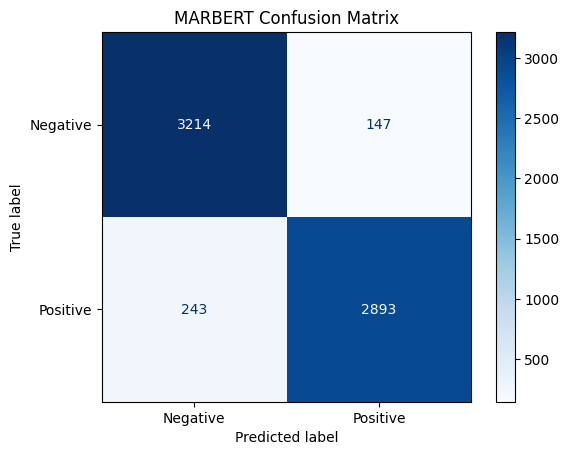

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

print("Confusion Matrix:")
print(cm)

# Extract values
tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Negative (TN): {tn}")
print(f"False Positive (FP): {fp}")
print(f"False Negative (FN): {fn}")
print(f"True Positive (TP): {tp}")

# Plot with blue color
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot(cmap="Blues")

plt.title("MARBERT Confusion Matrix")
plt.show()

### Model Comparison

The LSTM model from Day 3 and the MARBERT Transformer from Day 4 were trained on different datasets and addressed different tasks. The LSTM was applied to sequential ECG data, where its ability to preserve temporal order was important, while MARBERT was applied to Arabic text for sentiment classification. Therefore, their evaluation metrics should not be directly compared. Each model was evaluated within its own task, and the results demonstrate how different architectures are suitable for different types of sequential data.


### Core Model Selection

For the Arabic sentiment classification task, MARBERT will serve as the core model. MARBERT is a Transformer-based language model specifically designed for Arabic language understanding, making it well suited for handling Arabic text and its linguistic variations. In our experiments, MARBERT achieved a test accuracy of 94.00% and a Macro F1-score of 93.98%, demonstrating strong and balanced performance across the sentiment classes. The model also benefits from self-attention, which allows it to consider relationships between different words in the input sequence and capture contextual information more effectively. Therefore, MARBERT was selected as the core model for the Arabic text classification task.


### Conclusion

This day introduced the Transformer architecture and the self-attention mechanism as an alternative to recurrent neural networks. A pre-trained MARBERT model was fine-tuned for Arabic sentiment classification using the Hugging Face Transformers library. The model achieved a test accuracy of 94.00% and a Macro F1-score of 93.98%. The validation results showed that the best performance was achieved at Epoch 2, after which the validation performance gradually decreased while the training loss continued to decrease, indicating overfitting. Based on its strong and balanced performance and its suitability for Arabic language understanding, MARBERT was selected as the core model for the text classification task.
